   Actual  Predicted
0   85.75  87.759138
1   97.25  96.707637
2   89.50  90.060076
3   74.25  81.264815
Mean Absolute Error (MAE): 2.531597848736972
Mean Squared Error (MSE): 13.463025421380646
R² Score: 0.8042075494021789


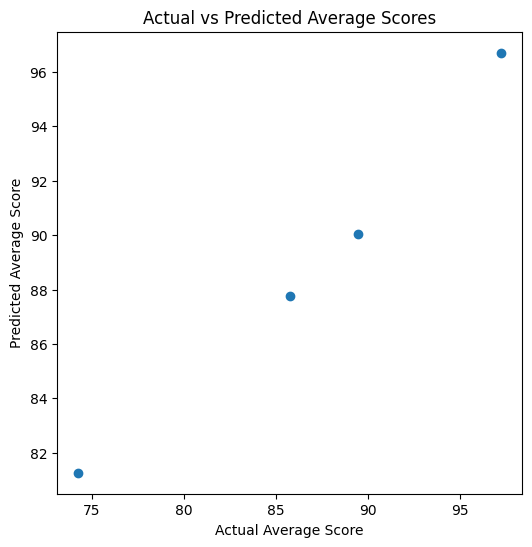

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("student_performance.csv")

# Encode categorical column
label_encoder = LabelEncoder()
df["Program"] = label_encoder.fit_transform(df["Program"])

# Create Average_Score column
df["Average_Score"] = (
    df["Python"] +
    df["Mathematics"] +
    df["Statistics"] +
    df["Machine_Learning"]
) / 4

# Select features and target
X = df[["Age", "Program", "Attendance"]]
y = df["Average_Score"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Comparison table
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

# Evaluation metrics
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Average Score")
plt.ylabel("Predicted Average Score")
plt.title("Actual vs Predicted Average Scores")
plt.show()